<center><h1>Last_First_HW2</h1></center>
<br>
<br>

Name: yiyi zheng
<br>
Github Username: yiyizheng111
<br>
USC ID: 7092417109

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

Get the Cycle Power Plant Data Set

In [4]:
df = pd.read_excel("Folds5x2_pp.xlsx", sheet_name="Sheet1")

df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Columns:", list(df.columns))

Number of rows: 9568
Number of columns: 5
Columns: ['AT', 'V', 'AP', 'RH', 'PE']


The dataset has **9568 rows and 5 columns**.

Each row is one hourly record. AT, V, AP, and RH are the predictors, and PE is the response.

#### ii. pairwise scatterplots of all the varianbles

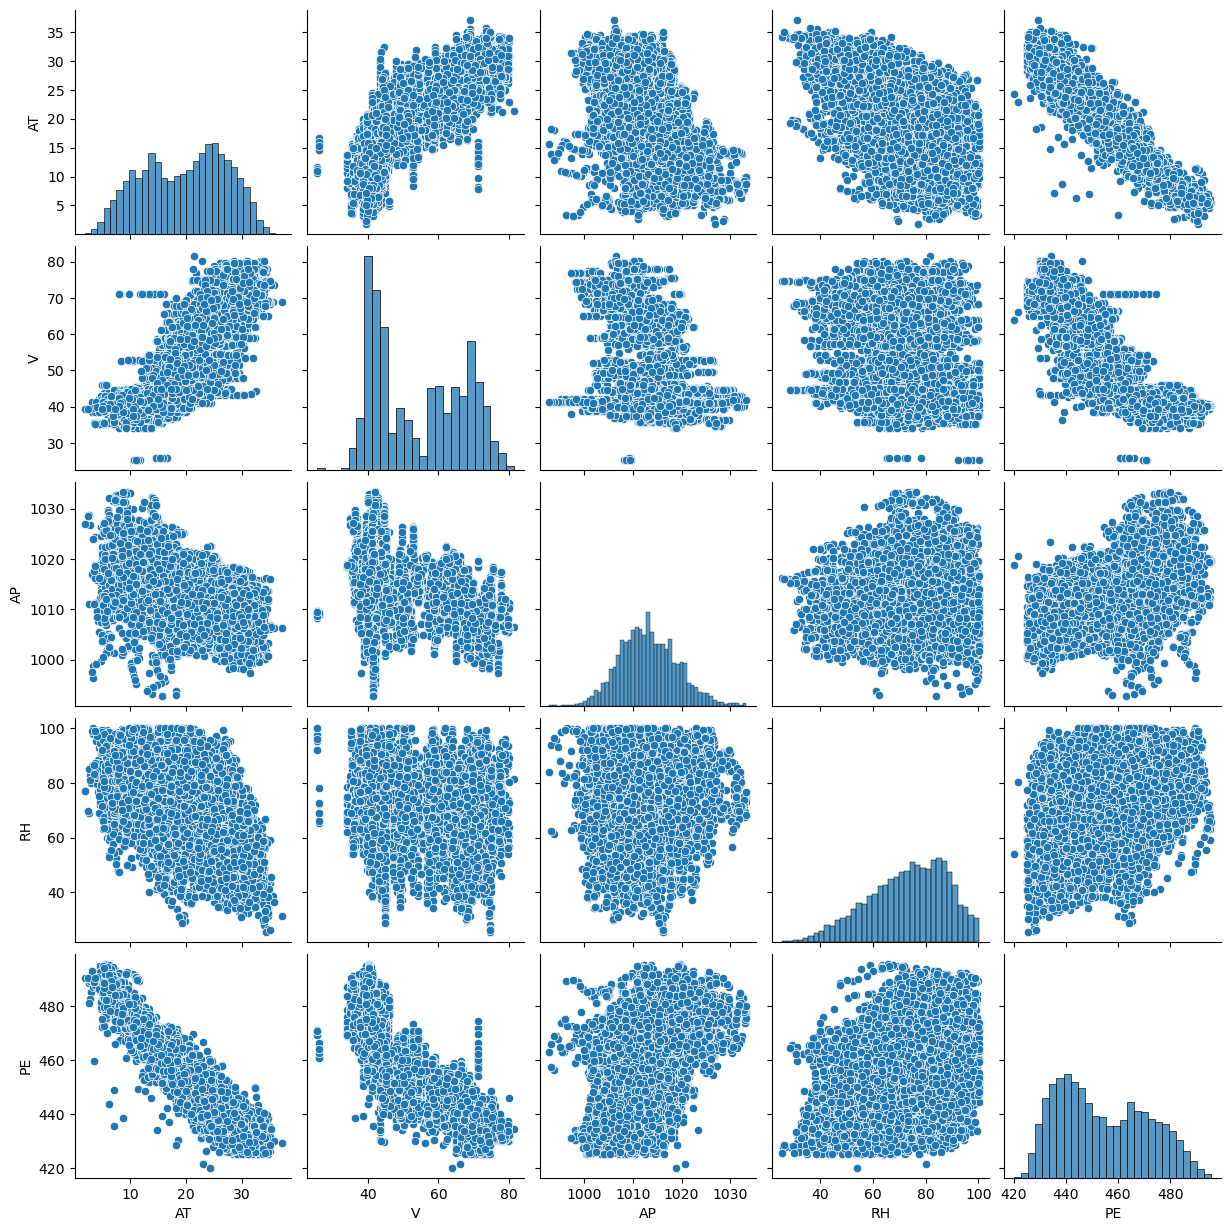

In [7]:
sns.pairplot(df)

plt.show()

AT has a strong negative relationship with PE. V also has a negative relationship with PE, while AP has a positive relationship with PE. RH has a weaker relationship with PE.

There are also some relationships among the predictors. For example, AT and V are positively related, while AT and AP are negatively related.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [8]:
summary = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Range": df.max() - df.min(),
    "Q1": df.quantile(0.25),
    "Q3": df.quantile(0.75)
})

summary["IQR"] = summary["Q3"] - summary["Q1"]

summary

,Mean,Median,Range,Q1,Q3,IQR
AT,19.651231,20.345,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,75.50,439.7500,468.43,28.6800


### (c) Simple Linear Regression

In [9]:
predictors = ["AT", "V", "AP", "RH"]

simple_results = {}

for x in predictors:
    model = smf.ols(f"PE ~ {x}", data=df).fit()
    simple_results[x] = model
    
    print("\n", x)
    print("Coefficient:", model.params[x])
    print("p-value:", model.pvalues[x])
    print("R-squared:", model.rsquared)


 AT
Coefficient: -2.1713199585178034
p-value: 0.0
R-squared: 0.8989475964148236

 V
Coefficient: -1.1681351265557118
p-value: 0.0
R-squared: 0.7565177870683979

 AP
Coefficient: 1.4898716733991118
p-value: 0.0
R-squared: 0.2687686564110676

 RH
Coefficient: 0.4556501022629794
p-value: 0.0
R-squared: 0.15193944023117567


All four predictors are statistically significant because their p-values are very small.

AT has the strongest simple linear relationship with PE, with the highest R-squared value. V is also strong, while AP and RH have weaker relationships with PE.

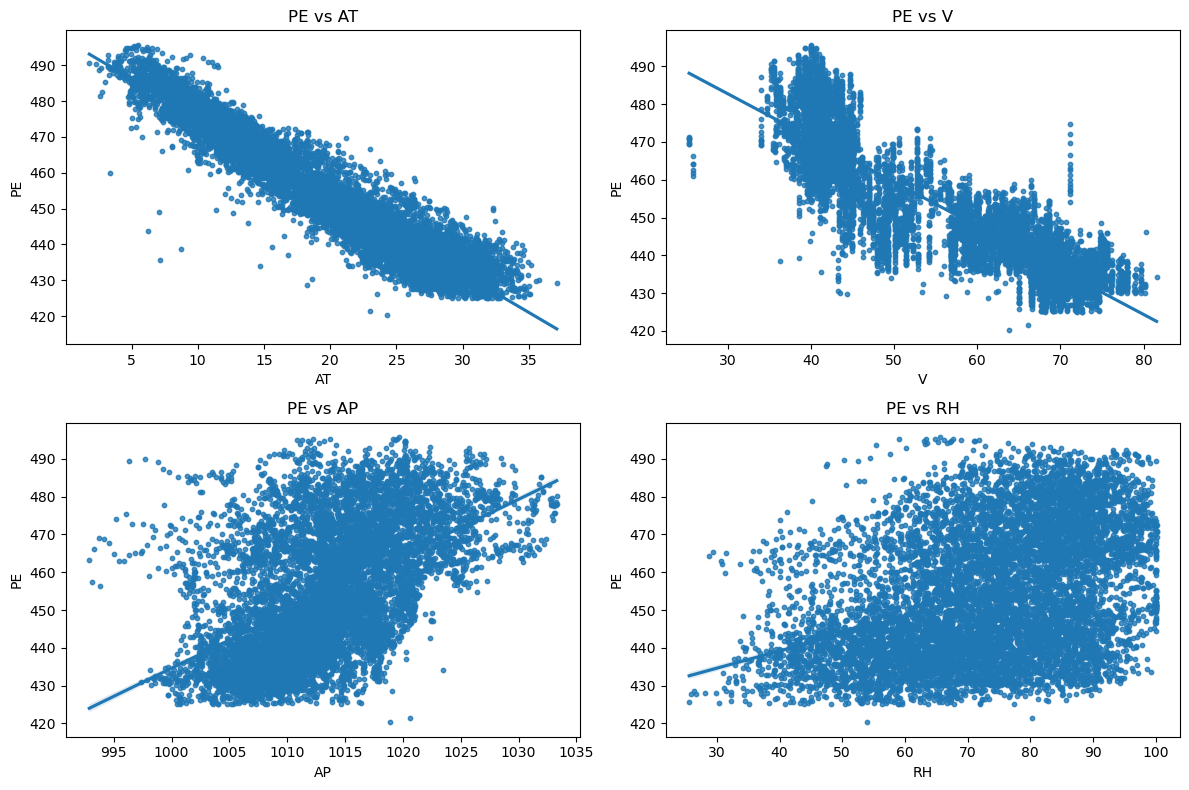

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, x in zip(axes.flatten(), predictors):
    sns.regplot(
        data=df,
        x=x,
        y="PE",
        ax=ax,
        scatter_kws={"s": 10}
    )
    ax.set_title(f"PE vs {x}")

plt.tight_layout()
plt.show()

There are a few possible outliers, especially for AT and V. However, they do not appear to be clear data errors, so I do not remove any observations from the four regression models.

### (d) Multiple Regression

In [11]:
X = df[["AT", "V", "AP", "RH"]]
y = df["PE"]

X = sm.add_constant(X)

multi_model = sm.OLS(y, X).fit()

print(multi_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:36:28   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

The multiple regression model has an R-squared of **0.929**.
AT, V, and RH have negative coefficients, while AP has a positive coefficient.
All four predictors have very small p-values, so we can reject the null hypothesis for AT, V, AP, and RH.

### (e) 1c Compare to 1d

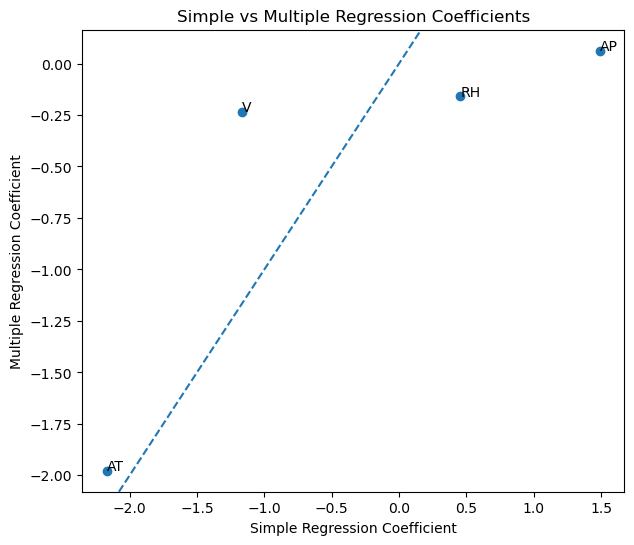

In [12]:
simple_coef = [simple_results[x].params[x] for x in predictors]
multiple_coef = [multi_model.params[x] for x in predictors]

plt.figure(figsize=(7, 6))

plt.scatter(simple_coef, multiple_coef)

for i, x in enumerate(predictors):
    plt.text(simple_coef[i], multiple_coef[i], x)

plt.xlabel("Simple Regression Coefficient")
plt.ylabel("Multiple Regression Coefficient")
plt.title("Simple vs Multiple Regression Coefficients")

plt.axline((0, 0), slope=1, linestyle="--")

plt.show()

The coefficients from the simple and multiple regression models are different.

AT changes only a little, but V, AP, and RH change more. RH even changes from a positive coefficient in the simple regression to a negative coefficient in the multiple regression. This may be because the predictors are related to each other.

### (f) Nonlinear Association

In [14]:
nonlinear_results = {}

for x in predictors:
    
    # standardize the predictor first
    z = (df[x] - df[x].mean()) / df[x].std()
    
    temp = pd.DataFrame({
        "PE": df["PE"],
        "X": z
    })
    
    model = smf.ols(
        "PE ~ X + I(X**2) + I(X**3)",
        data=temp
    ).fit()
    
    nonlinear_results[x] = model
    
    print("\n", x)
    print(model.summary().tables[1])


 AT
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    452.7081      0.074   6085.240      0.000     452.562     452.854
X            -18.1075      0.108   -167.160      0.000     -18.320     -17.895
I(X ** 2)      1.8080      0.054     33.381      0.000       1.702       1.914
I(X ** 3)      1.1071      0.049     22.594      0.000       1.011       1.203

 V
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    451.2137      0.144   3124.596      0.000     450.931     451.497
X            -15.8881      0.185    -85.722      0.000     -16.251     -15.525
I(X ** 2)      3.0969      0.125     24.714      0.000       2.851       3.343
I(X ** 3)      0.2757      0.112      2.465      0.014       0.056       0.495

 AP
                 coef    std err      

There is evidence of nonlinear association for all four predictors.

For AT, V, and AP, the higher-order terms are statistically significant. For RH, the quadratic term is not significant, but the cubic term is significant.

### (g) Interactions of Predictors

In [15]:
interaction_model = smf.ols(
    "PE ~ (AT + V + AP + RH) ** 2",
    data=df
).fit()

interaction_pvalues = interaction_model.pvalues[
    interaction_model.pvalues.index.str.contains(":")
]

interaction_pvalues

AT:V     3.333358e-117
AT:AP     4.520509e-01
AT:RH     1.216944e-10
V:AP      2.877026e-07
V:RH      8.619366e-02
AP:RH     3.360557e-02
dtype: float64

There are several significant interaction terms.

AT:V, AT:RH, V:AP, and AP:RH are statistically significant. AT:AP and V:RH are not significant at the 0.05 level.

### (h) Improvement

In [16]:
X = df[["AT", "V", "AP", "RH"]]
y = df["PE"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

train_pred = linear_model.predict(X_train)
test_pred = linear_model.predict(X_test)

linear_train_mse = mean_squared_error(y_train, train_pred)
linear_test_mse = mean_squared_error(y_test, test_pred)

print("Linear Regression")
print("Train MSE:", linear_train_mse)
print("Test MSE:", linear_test_mse)

Linear Regression
Train MSE: 20.580839725738695
Test MSE: 21.239856938225508


In [18]:
from itertools import combinations

base = ["AT", "V", "AP", "RH"]

# center predictors using training means
train_h = X_train[base].copy()
test_h = X_test[base].copy()

train_means = X_train[base].mean()

train_h = train_h - train_means
test_h = test_h - train_means


# quadratic terms
for x in base:
    train_h[x + "2"] = train_h[x] ** 2
    test_h[x + "2"] = test_h[x] ** 2


# interaction terms
interaction_terms = []

for x1, x2 in combinations(base, 2):
    name = x1 + "_" + x2
    
    train_h[name] = train_h[x1] * train_h[x2]
    test_h[name] = test_h[x1] * test_h[x2]
    
    interaction_terms.append(name)


quadratic_terms = [x + "2" for x in base]
higher_terms = quadratic_terms + interaction_terms


# remove insignificant higher-order terms using p-values
while True:
    
    current_terms = base + higher_terms
    
    X_fit = sm.add_constant(
        train_h[current_terms],
        has_constant="add"
    )
    
    model = sm.OLS(y_train, X_fit).fit()
    
    higher_pvalues = model.pvalues[higher_terms]
    
    if higher_pvalues.max() <= 0.05:
        break
    
    remove_term = higher_pvalues.idxmax()
    higher_terms.remove(remove_term)


final_terms = base + higher_terms

X_train_final = sm.add_constant(
    train_h[final_terms],
    has_constant="add"
)

X_test_final = sm.add_constant(
    test_h[final_terms],
    has_constant="add"
)

final_model = sm.OLS(
    y_train,
    X_train_final
).fit()


train_pred2 = final_model.predict(X_train_final)
test_pred2 = final_model.predict(X_test_final)

improved_train_mse = mean_squared_error(
    y_train,
    train_pred2
)

improved_test_mse = mean_squared_error(
    y_test,
    test_pred2
)


print("Terms kept:")
print(final_terms)

print("\nImproved Regression")
print("Train MSE:", improved_train_mse)
print("Test MSE:", improved_test_mse)

Terms kept:
['AT', 'V', 'AP', 'RH', 'AT2', 'AP2', 'RH2', 'AT_V', 'AT_AP', 'AT_RH', 'AP_RH']

Improved Regression
Train MSE: 17.89084277318502
Test MSE: 18.660040495062642


The model is improved after adding significant interaction and quadratic terms.

The train MSE decreases from **20.58** to **17.89**, and the test MSE decreases from **21.24** to **18.66**.

### (i) KNN

Raw Features
Best k: 5
Best Test MSE: 15.726819842563568

Normalized Features
Best k: 4
Best Test MSE: 14.305669422675024


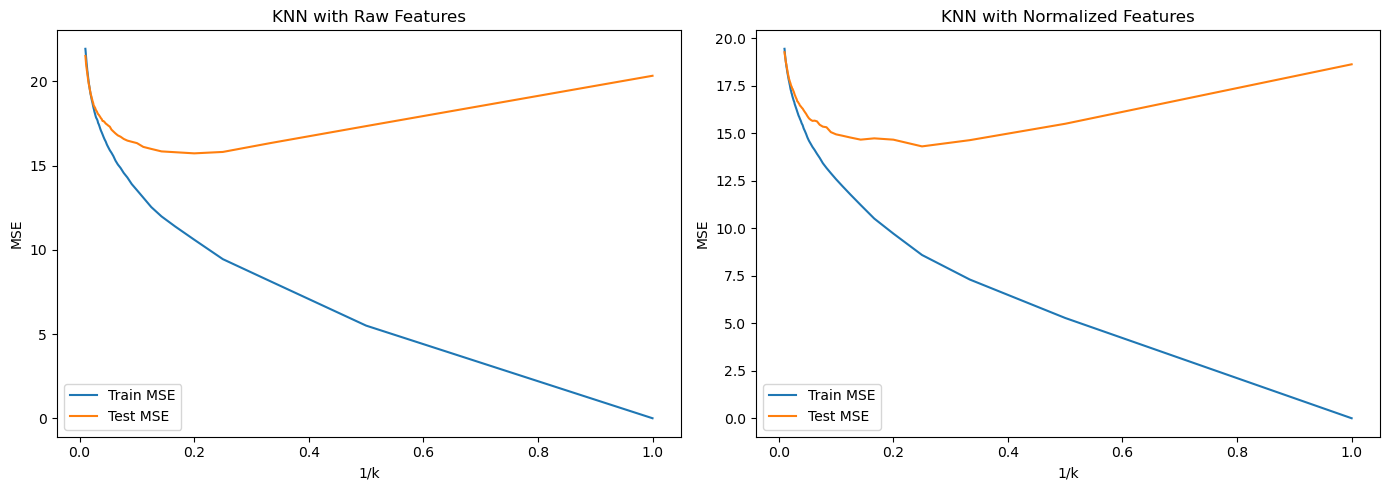

In [19]:
k_values = range(1, 101)

# raw features
raw_train_mse = []
raw_test_mse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)
    
    raw_train_mse.append(mean_squared_error(y_train, train_pred))
    raw_test_mse.append(mean_squared_error(y_test, test_pred))


best_raw_k = k_values[np.argmin(raw_test_mse)]
best_raw_test_mse = min(raw_test_mse)


# normalized features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

norm_train_mse = []
norm_test_mse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    train_pred = knn.predict(X_train_scaled)
    test_pred = knn.predict(X_test_scaled)
    
    norm_train_mse.append(mean_squared_error(y_train, train_pred))
    norm_test_mse.append(mean_squared_error(y_test, test_pred))


best_norm_k = k_values[np.argmin(norm_test_mse)]
best_norm_test_mse = min(norm_test_mse)


print("Raw Features")
print("Best k:", best_raw_k)
print("Best Test MSE:", best_raw_test_mse)

print("\nNormalized Features")
print("Best k:", best_norm_k)
print("Best Test MSE:", best_norm_test_mse)


# plots
inverse_k = [1 / k for k in k_values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(inverse_k, raw_train_mse, label="Train MSE")
axes[0].plot(inverse_k, raw_test_mse, label="Test MSE")
axes[0].set_title("KNN with Raw Features")
axes[0].set_xlabel("1/k")
axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].plot(inverse_k, norm_train_mse, label="Train MSE")
axes[1].plot(inverse_k, norm_test_mse, label="Test MSE")
axes[1].set_title("KNN with Normalized Features")
axes[1].set_xlabel("1/k")
axes[1].set_ylabel("MSE")
axes[1].legend()

plt.tight_layout()
plt.show()

### (j ) Compare KNN and Linear

The normalized KNN model has the lowest test MSE of **14.31** with k = 4.
The improved linear regression model has a test MSE of **18.66**. Therefore, KNN performs better on the test data. This suggests that the relationship between the predictors and PE may not be completely linear.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

A flexible method would perform better.

Since the sample size is very large and the number of predictors is small, there is enough data to fit a more flexible model without too much risk of overfitting.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

An inflexible method would perform better.

Since the number of predictors is very large and the sample size is small, a flexible method can easily overfit the training data. An inflexible method can reduce this problem.

### (c) The relationship between the predictors and response is highly non-linear.

A flexible method would perform better.

Since the relationship is highly non-linear, a flexible method can better capture the complex pattern between the predictors and the response.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

An inflexible method would perform better.

When the error variance is very high, a flexible method may fit the noise in the training data. An inflexible method is less likely to overfit the noise.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

The Euclidean distance is

$$
d = \sqrt{(X_1-0)^2 + (X_2-0)^2 + (X_3-0)^2}.
$$

For the six observations:

1. $d_1=\sqrt{0^2+3^2+0^2}=3$
2. $d_2=\sqrt{2^2+0^2+0^2}=2$
3. $d_3=\sqrt{0^2+1^2+3^2}=\sqrt{10}\approx3.162$
4. $d_4=\sqrt{0^2+1^2+2^2}=\sqrt{5}\approx2.236$
5. $d_5=\sqrt{(-1)^2+0^2+1^2}=\sqrt{2}\approx1.414$
6. $d_6=\sqrt{1^2+1^2+1^2}=\sqrt{3}\approx1.732$

### (b) What is our prediction with K = 1? Why?

For K = 1, the prediction is **Green**.

Observation 5 is the closest point to the test point, with distance $\sqrt{2}\approx1.414$, and its class is Green.

### (c) What is our prediction with K = 3? Why?

For K = 3, the prediction is **Red**.

The three closest observations are 5, 6, and 2. Their classes are Green, Red, and Red. Since Red is the majority class, the prediction is Red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

A small value of K would be better.

A small K gives a more flexible decision boundary, so it can better capture a highly non-linear pattern. A large K would make the decision boundary smoother and less flexible.